## MNIST Fashion Dataset - Item Prediction

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Let's see the length of training and testing sets:

In [ ]:
len(X_train), len(X_test)

(60000, 10000)

How about the resolution of the photos and the visualisation of one?

Resolution of photos (height, width): (28, 28)


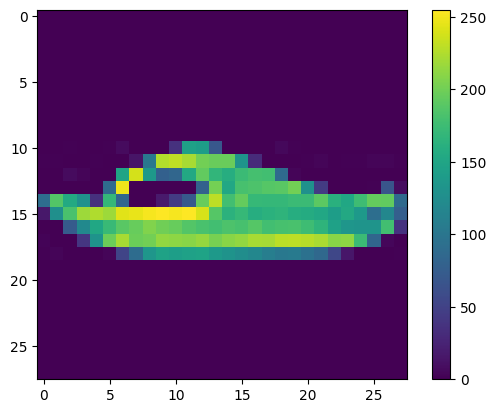

The visualized item is a: Sandal (label: 5)


In [ ]:
print(f"Resolution of photos (height, width): {X_train.shape[1:]}")

import random; image_index = random.randint(0, len(X_train))
plt.imshow(X_train[image_index])
plt.colorbar()
plt.grid(False)
plt.show()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
item_label = y_train[image_index]
item_name = class_names[item_label]
print(f"The visualized item is a: {item_name} (label: {item_label})")

In [ ]:
X_train.shape

(60000, 28, 28)

In [ ]:
# We do not want three-dimensional array. Instead, we need to reduce dimensionality.

X_train, X_test = X_train.reshape(len(X_train), 28*28), X_test.reshape(len(X_test), 28*28)
print("Shape of the flattened training set:", X_train.shape)
print("Shape of the flattened testing set:", X_test.shape)

Shape of the flattened training set: (60000, 784)
Shape of the flattened testing set: (10000, 784)


In [ ]:
# Let's wrap tf.keras to just "keras":
from tensorflow import keras

In [ ]:
model = keras.Sequential([
    keras.layers.Dense(10, input_shape=(784,), activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

model.fit(X_train, y_train, epochs=10)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1538 - loss: 22.2389
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1755 - loss: 12.0645
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1767 - loss: 11.3844
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.1836 - loss: 10.4680
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.1729 - loss: 9.9641
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1709 - loss: 10.0134
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1625 - loss: 10.4168
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1696 - loss: 10.0821
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.1702 - loss: 9.6682
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1670 - loss: 9.2597


These numbers for accuracy score are extremely low.

I presume that the problem is data normalisation.

In [ ]:
X_train, X_test = X_train/255, X_test/255

Now let's run again:

In [ ]:
model = keras.Sequential([
    keras.layers.Dense(10, input_shape=(784,), activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

model.fit(X_train, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7427 - loss: 0.7771
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8411 - loss: 0.4666
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8507 - loss: 0.4393
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8578 - loss: 0.4155
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8581 - loss: 0.4079


In [ ]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8431 - loss: 0.4444


[0.45598822832107544, 0.8396999835968018]

Let's test a specific one.

In [ ]:
# First: assigning the predicted set
predicted_set = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


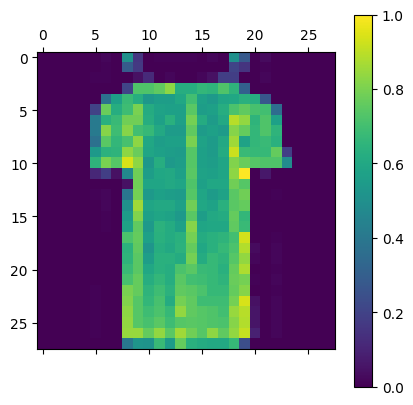

In [ ]:
# Second: printing a random one
import random; random_num = random.randint(0, len(X_test))

plt.matshow(X_test[random_num].reshape(28, 28))
plt.colorbar(); plt.show()

In [ ]:
predicted_set[random_num]

array([9.8602802e-01, 4.2471793e-03, 1.3044278e-01, 5.2888441e-01,
       2.2528682e-02, 4.4663015e-12, 9.1531157e-01, 4.1999990e-10,
       2.0946989e-02, 1.9578819e-08], dtype=float32)

It prints a NumPy array which we fairly do not understand anything.

**Solution**: `np.argmax`

In [ ]:
predicted_label = np.argmax(predicted_set[random_num])

## But before that:

We need to initialise the class names in order to understand which exact item it will be.

In [ ]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

**Now:**

In [ ]:
predicted_item_name = class_names[predicted_label]
print(f"The model predicts this item is a: {predicted_item_name} (label: {predicted_label})")

The model predicts this item is a: T-shirt/top (label: 0)


All done.
![alt_img](https://i1.sndcdn.com/artworks-tCLQZAMS5G99Yyhd-ZpIUVQ-t500x500.jpg)